# Reading HFTS-2 Cross-Well Fiber Data

A general-purpose notebook for loading and visualizing the OptaSense cross-well (CWC)
low-frequency DAS data from the HFTS-2 fiber dataset (DOE/NETL Energy Data eXchange),
built on [DASCore](https://github.com/DASDAE/dascore) (`pip install dascore`).

## Dataset anatomy

- Projects are folders named `Anadarko_<TREATMENT>_(<MONITOR>)_CWC` spread across the
  `optasense-hfp-cwc_zip_a ... _d` archives (the B1H-on-B4H project is additionally
  split by stage range).
- Each project holds `Input/` products as 5-minute PRODML v2.0 HDF5 chunks
  (`Acquisition/Raw[0]/RawData`, channels x time): low-frequency phase at `0.1 Hz` and
  `1 Hz` output rates plus differentiated `... Diff` variants, along with `Curves`
  (treatment data) and DTS.  Some projects prefix the product folders with `FBE `.
- Channel-to-depth calibration comes in two flavors: a `ChannelDepths/*.csvh` table
  (channel, depth in m KB), or `Well/Fibres.xml` with (opticalDistance,
  physicalDistance) anchor points defining a linear map.
- Stage starts, treated perforation intervals, and OptaSense-picked fracture hits are
  in the `HFTS-2 <MON> Fracture Map from <TREAT>_OptaSense*.xlsx` workbooks under
  `Anadarko CWC Reports`.

## Physics

Raw values are optical phase in counts of rad/10430.4; strain follows
$\varepsilon = \phi\,\lambda/(4\pi n G \xi)$ with gauge length $G = 7.147$ m and
refractive index $n = 1.4682$ from the acquisition headers
(e.g. `sensor_2019-03-22T000723Z.h5`), $\lambda = 1550$ nm (assumed C-band
wavelength), and photoelastic scaling $\xi = 0.79$ (standard fused-silica value).

**Caveat:** in this low-frequency band the measurement mixes strain and temperature
(tension and/or warming map to positive values); the interpretation caveats in the
OptaSense CWC reports apply.

In [1]:
import glob, re, os                                    # file discovery and name parsing
import numpy as np                                     # array math
import dascore as dc                                   # DAS data I/O and processing (DASDAE)
from datetime import datetime, timedelta, timezone     # stage windows are defined in UTC
import matplotlib.pyplot as plt                        # waterfall rendering

print('dascore', dc.__version__)                       # record the library version for reproducibility

FIBER_ROOT = "../inputs/field_data/fiber"   # packaged LF-DAS windows (relative to notebooks/)                     # dataset root
import os
FIGDIR = "../figures"  # created on demand (relative to notebooks/)
os.makedirs(FIGDIR, exist_ok=True)
FT = 0.3048                                            # meters per foot: tables are metric, well data is in ft

# --- phase-to-strain conversion constants ---
LAM = 1550e-9                                          # interrogator wavelength (m): C-band assumption
N_IDX = 1.4682                                         # fiber refractive index (acquisition header)
GAUGE = 7.1466665                                      # gauge length (m) over which phase is measured (header)
XI = 0.79                                              # photoelastic scaling factor for fused silica
PHASE_UNIT = 10430.4                                   # raw integer counts per radian of optical phase (header)
# microstrain per raw count: counts -> radians -> strain, then x1e6
UE_PER_COUNT = (1.0/PHASE_UNIT) * LAM / (4*np.pi*N_IDX*GAUGE*XI) * 1e6

dascore 0.1.18


## Generic readers

Everything below is project-agnostic: locating the product folder (with or without the
`FBE ` prefix), indexing the 5-minute files by the timestamp in their names, resolving
the channel-to-depth calibration from whichever source the project ships, and merging a
time window into a single DASCore `Patch`.  Windows are cached so repeated zooms do not
re-read the files.

In [2]:
def product_dir(project, product='0.1 Hz'):
    """Return the product folder, tolerating the 'FBE ' prefix used by some projects."""
    for name in (f'FBE {product}', product):
        d = f'{project}/Input/{name}'
        if os.path.isdir(d):
            return d
    raise FileNotFoundError(f'no {product!r} folder under {project}/Input')

def fname_time(p):
    """Parse the acquisition start time encoded in a chunk file name."""
    m = re.search(r'sensor_(\d{4}-\d{2}-\d{2}T\d{6})Z', p)              # e.g. sensor_2019-03-25T014500Z
    return datetime.strptime(m.group(1), '%Y-%m-%dT%H%M%S').replace(tzinfo=timezone.utc)

def index_files(project, product='0.1 Hz'):
    """Return (paths, start times) of all 5-minute chunks of a product, time-ordered."""
    files = sorted(glob.glob(f'{product_dir(project, product)}/sensor_*.h5'))
    return files, [fname_time(p) for p in files]

def n_loci_of(path):
    """Channel count of a chunk, read from its PRODML header via a DASCore patch."""
    return dc.spool(path)[0].shape[0]                  # dims are (distance, time)

def load_depth_table(project, n_loci, dx=1.0209523):
    """Channel -> measured depth (ft), from whichever calibration source the project has."""
    depth_ft = np.full(n_loci, np.nan)                 # NaN marks channels with no calibrated depth
    csvh = glob.glob(f'{project}/ChannelDepths/All_DAS_fibre_depth_table.csvh')
    if csvh:                                           # flavor 1: explicit per-channel table (m KB)
        lines = open(csvh[0]).read().splitlines()
        rows = [l.split(',') for l in lines[lines.index('~DATA')+3:] if ',' in l]
        ch = [int(r[0]) for r in rows]
        depth_ft[ch] = np.array([float(r[1]) for r in rows]) / FT
        return depth_ft
    xml = open(f'{project}/Well/Fibres.xml').read()    # flavor 2: linear map between anchor points
    pts = re.findall(r'<calibrationPoints>.*?<opticalDistance uom="m">(.*?)</opticalDistance>.*?'
                     r'<physicalDistance uom="m">(.*?)</physicalDistance>', xml, re.S)
    (o0, p0), (o1, p1) = [(float(a), float(b)) for a, b in pts[:2]]   # e.g. Top of Well, End of Fiber
    optical = np.arange(n_loci) * dx                   # optical distance of every channel (m)
    depth_ft[:] = (p0 + (optical - o0) * (p1 - p0) / (o1 - o0)) / FT  # linear optical->depth, in ft
    depth_ft[optical < o0] = np.nan                    # lead-in fiber before the wellhead
    return depth_ft

_window_cache = {}                                     # (project, t0, t1, product) -> (Patch, hours)

def load_window(project, t0, t1, product='0.1 Hz'):
    """Merge the 5-minute chunks covering [t0, t1] into one microstrain-change Patch."""
    key = (project, t0, t1, product)
    if key in _window_cache:                           # repeated zooms reuse the loaded window
        return _window_cache[key]
    files, ftimes = index_files(project, product)
    # keep files whose start falls in the window (one extra before t0 covers the first samples)
    sel = [p for p, t in zip(files, ftimes) if t0 - timedelta(minutes=5) <= t <= t1]
    # read each file into a Patch; clear the 'path' attr so the merge does not flag conflicts
    patches = [dc.spool(p)[0].update_attrs(path='') for p in sel]
    # merge along time, then trim exactly to the window (datetime64 matches the time coordinate)
    pa = dc.spool(patches).chunk(time=None)[0].transpose('distance', 'time')
    pa = pa.select(time=(np.datetime64(t0.replace(tzinfo=None)),
                         np.datetime64(t1.replace(tzinfo=None))))
    ue = pa.data.astype(np.float64) * UE_PER_COUNT     # raw phase counts -> microstrain
    ue -= ue[:, :6].mean(axis=1, keepdims=True)        # reference to the first minute: strain CHANGE
    pa = pa.new(data=ue)                               # repackage as a Patch, keeping coords/attrs
    t = pa.get_coord('time').values                    # datetime64 stamps of the merged record
    hrs = (t - t[0]) / np.timedelta64(1, 'h')          # elapsed hours from window start (plot axis)
    _window_cache[key] = (pa, hrs)
    return pa, hrs

## Case registry and waterfall plotting

A *case* bundles everything needed to display one treatment stage on one monitor fiber:
the project folder, the wells, the stage window (start of the stage to start of the
next), the treated perforation interval, and the OptaSense-picked fracture hits from the
fracture-map workbooks.

`plot_case` accepts zoom controls: `tlim=(h0, h1)` (hours from stage start),
`dlim=(shallow, deep)` (ft MD), and `rescale_clim=True` to stretch the color scale to
the zoomed window; pass `save=False` when zooming so saved figures keep the full
extent.

In [3]:
def find_project(name):
    """Locate a project folder under FIBER_ROOT, with or without the archive
    zip level: the packaged subset holds projects directly
    (fiber/<project>), the full EDX archive wraps them in the download
    folders (fiber_data/optasense-hfp-cwc_zip_*/<project>)."""
    for pattern in (f'{FIBER_ROOT}/{name}', f'{FIBER_ROOT}/*/{name}'):
        hit = glob.glob(pattern)
        if hit:
            return hit[0]
    raise FileNotFoundError(f'project {name!r} not found under {FIBER_ROOT}')

# metadata sources: 'HFTS-2 B3H Fracture Map from B1H_OptaSense_final.xlsx' and
# 'HFTS-2 B4H Fracture Map from B2H_OptaSense_final.xlsx' (Anadarko CWC Reports)
CASES = {
    'B1H-09@B3H': dict(project=find_project('Anadarko_B1H_(B3H)_CWC'), treat='B1H', mon='B3H', stage=9,
                       t0=datetime(2019, 3, 22,  4, 16, 27, tzinfo=timezone.utc),
                       t1=datetime(2019, 3, 22, 11, 29, 14, tzinfo=timezone.utc),
                       perf=(17148, 17328), hits=[17042.0]),
    'B1H-20@B3H': dict(project=find_project('Anadarko_B1H_(B3H)_CWC'), treat='B1H', mon='B3H', stage=20,
                       t0=datetime(2019, 3, 25,  1, 45, 17, tzinfo=timezone.utc),
                       t1=datetime(2019, 3, 25,  7, 24, 16, tzinfo=timezone.utc),
                       perf=(14926, 15090), hits=[14801.0, 14871.0]),
    'B2H-28@B4H': dict(project=find_project('Anadarko_B2H_(B4H)_CWC'), treat='B2H', mon='B4H', stage=28,
                       t0=datetime(2019, 4, 8, 21, 41, 45, tzinfo=timezone.utc),
                       t1=datetime(2019, 4, 9,  4, 32,  1, tzinfo=timezone.utc),
                       perf=(12395, 12676),
                       hits=[12500.1, 12538.0, 12573.0, 12624.0, 12658.0, 12724.9, 12757.9]),
}

def plot_case(key, save=True, tlim=None, dlim=None, rescale_clim=False, save_suffix=""):
    """Render strain-change and strain-rate waterfalls for one case.

    save         : write the figure to FIGDIR (use False when zooming, so the saved
                   figures keep the full stage extent)
    tlim         : (start, end) in hours from stage start -- zooms the time axis
    dlim         : (shallow, deep) in ft MD -- zooms the depth axis
    rescale_clim : compute the color limits from the zoomed window only
    save_suffix  : additional suffix for the saved figure filename
    """
    cfg = CASES[key]                                   # project, wells, window, perfs, and picks
    pa, hrs = load_window(cfg['project'], cfg['t0'], cfg['t1'])       # cached merged window
    rate = pa.differentiate('time').data * 60          # time derivative: strain rate in ue/min

    # channel -> depth for THIS project's monitor fiber (channel count from the data itself)
    depth_ft = load_depth_table(cfg['project'], n_loci=pa.shape[0])
    if cfg.get('perf'):                                # lateral monitor: window around the perfs
        mask = (depth_ft > cfg['perf'][0] - 1500) & (depth_ft < cfg['perf'][1] + 1500)
    else:                                              # no perf projection: show the calibrated fiber
        mask = ~np.isnan(depth_ft)
    order = np.where(mask)[0][np.argsort(depth_ft[mask])]   # channel indices sorted by depth
    d = depth_ft[order]                                # depth axis (ft MD) for the plots

    # color-limit window: full extent by default, or the zoom when rescale_clim is set
    tmask = np.ones_like(hrs, dtype=bool)
    dmask = np.ones_like(d, dtype=bool)
    if rescale_clim and tlim is not None:
        tmask = (hrs >= tlim[0]) & (hrs <= tlim[1])
    if rescale_clim and dlim is not None:
        dmask = (d >= min(dlim)) & (d <= max(dlim))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax, P, label, title in ((ax1, pa.data[order], r'strain change ($\mu\varepsilon$)', 'strain change'),
                                (ax2, rate[order], r'strain rate ($\mu\varepsilon$/min)', 'strain rate')):
        lim = np.nanpercentile(np.abs(P[np.ix_(dmask, tmask)]), 98)   # symmetric 98th-pct color limits
        im = ax.pcolormesh(hrs, d, P, cmap='seismic', vmin=-lim, vmax=lim, shading='auto')
        plt.colorbar(im, ax=ax, label=label)
        if cfg.get('perf'):                            # gray band: treated perf interval (by MD)
            ax.axhspan(*cfg['perf'], color='k', alpha=0.12)
        for h in cfg['hits']:                          # dashed lines: picked fracture hits on the monitor
            ax.axhline(h, ls='--', color='k', lw=0.8)
        if tlim is not None:
            ax.set_xlim(*tlim)                         # zoom the time axis
        ax.set_xlabel('Hours from stage start'); ax.set_title(title)
    ax1.set_ylabel(f"{cfg['mon']} measured depth (ft)")
    if dlim is not None:
        ax1.set_ylim(max(dlim), min(dlim))             # zoom depth axis (deep at bottom)
    else:
        ax1.invert_yaxis()                             # full range, depth increasing downward
    fig.suptitle(f"HFTS-2: {cfg['treat']} Stage {cfg['stage']} treatment, "
                 f"monitored on the {cfg['mon']} fiber (LF-DAS, 10 s sampling)")
    fig.tight_layout()
    if save:                                           # file name matches the thesis \\includegraphics
        fig.savefig(f"{FIGDIR}/hfts2_{cfg['treat'].lower()}_stage{cfg['stage']:02d}_{cfg['mon'].lower()}{save_suffix}.png",
                    dpi=300, bbox_inches='tight')
    plt.show()

## B1H Stages 9 and 20 on the B3H fiber

The stage pair analyzed by Haffener et al. (2022, SPE-209123) in their new-rock versus
reactivation framework, monitored on the adjacent B3H fiber.

Output()

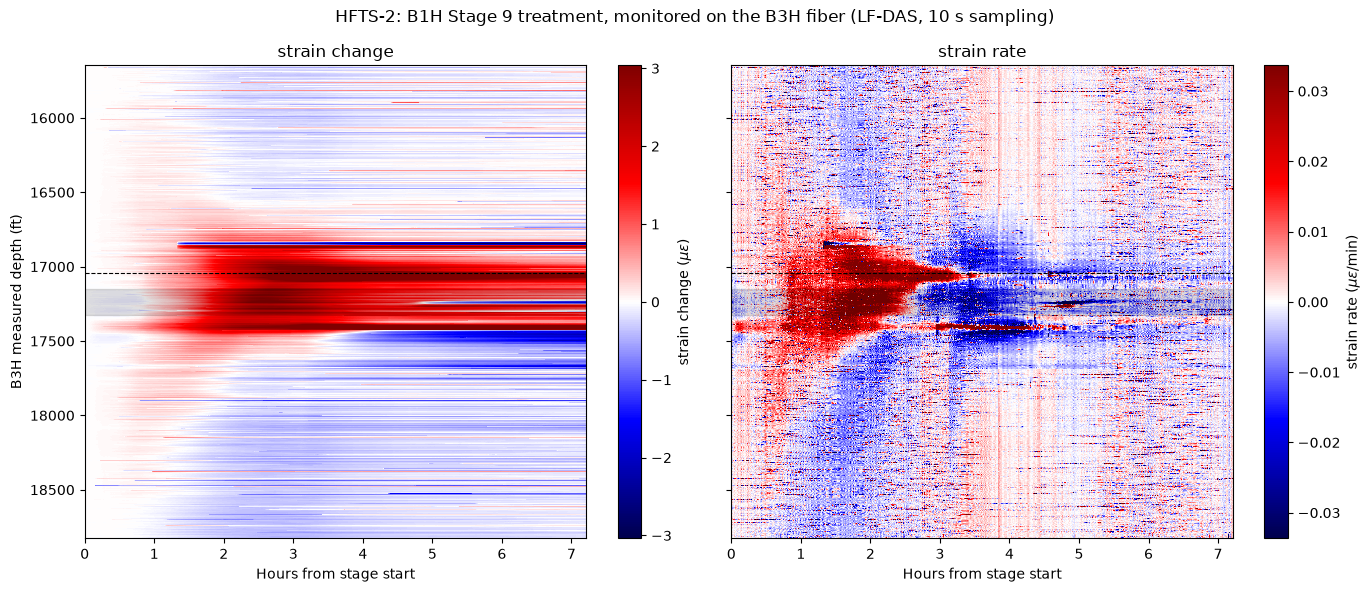

In [4]:
plot_case('B1H-09@B3H')

Output()

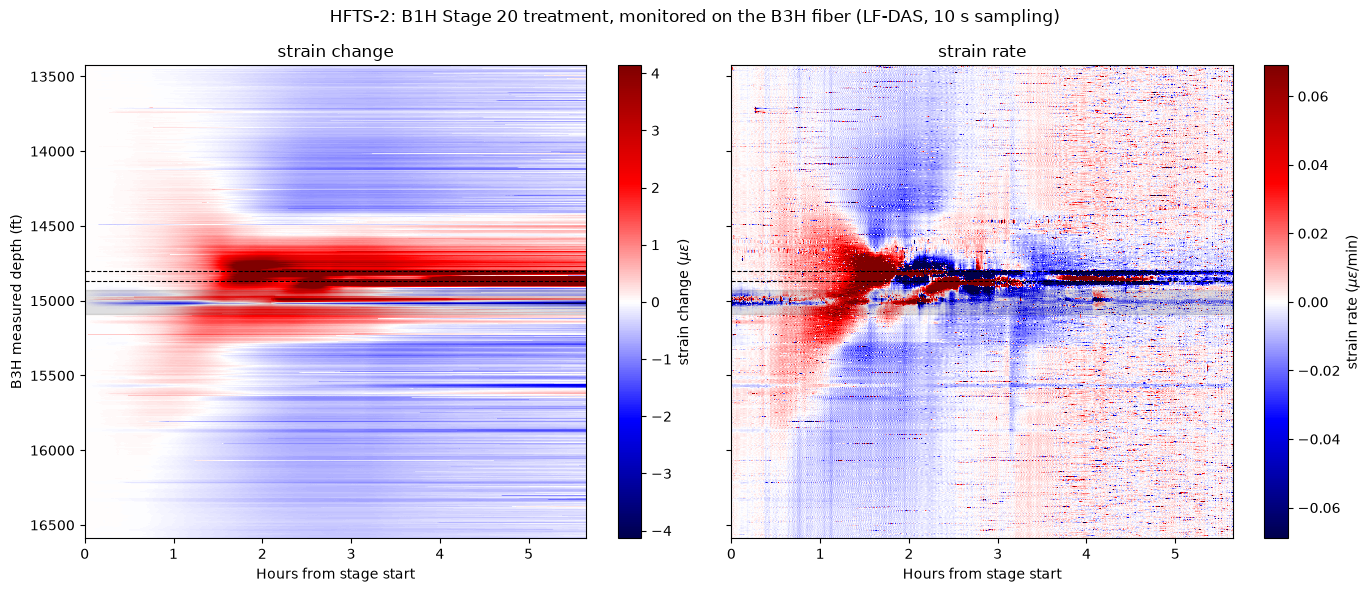

In [5]:
plot_case('B1H-20@B3H')

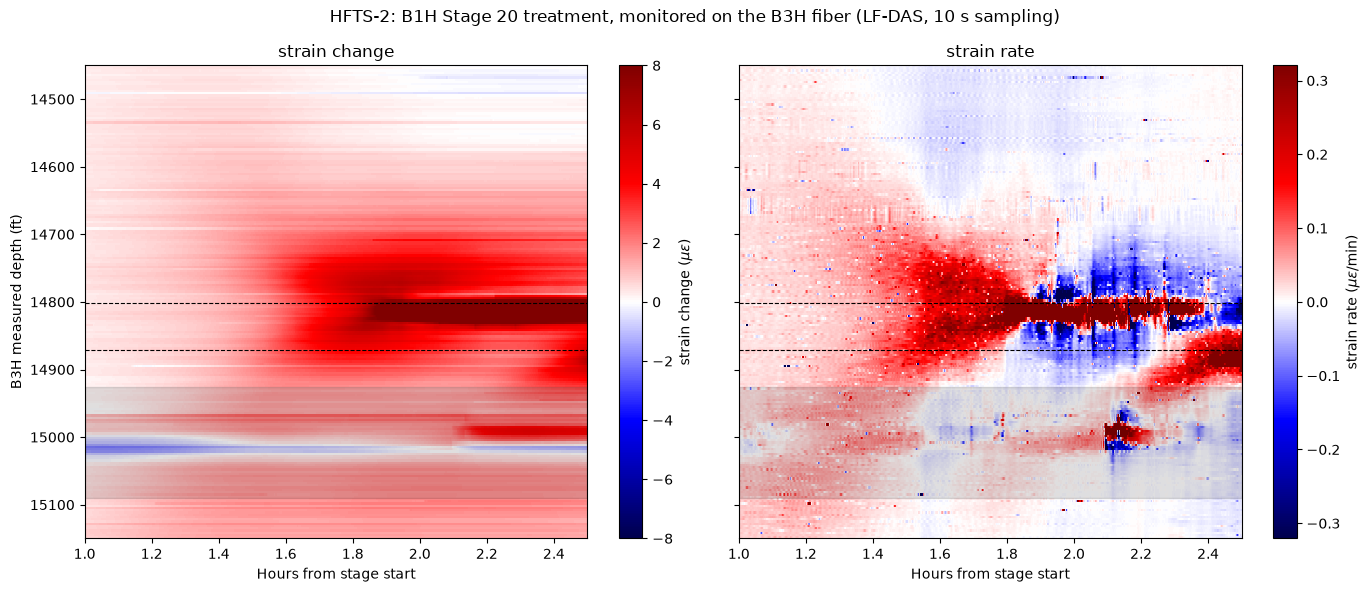

In [6]:
# zoomed view: fracture-hit corridor of stage 20, color scale restretched to the window
plot_case('B1H-20@B3H', save=True, tlim=(1.0, 2.5), dlim=(14450, 15150), rescale_clim=True, save_suffix="_new_fracture_hits")

## B2H Stage 28 on the B4H fiber

Output()

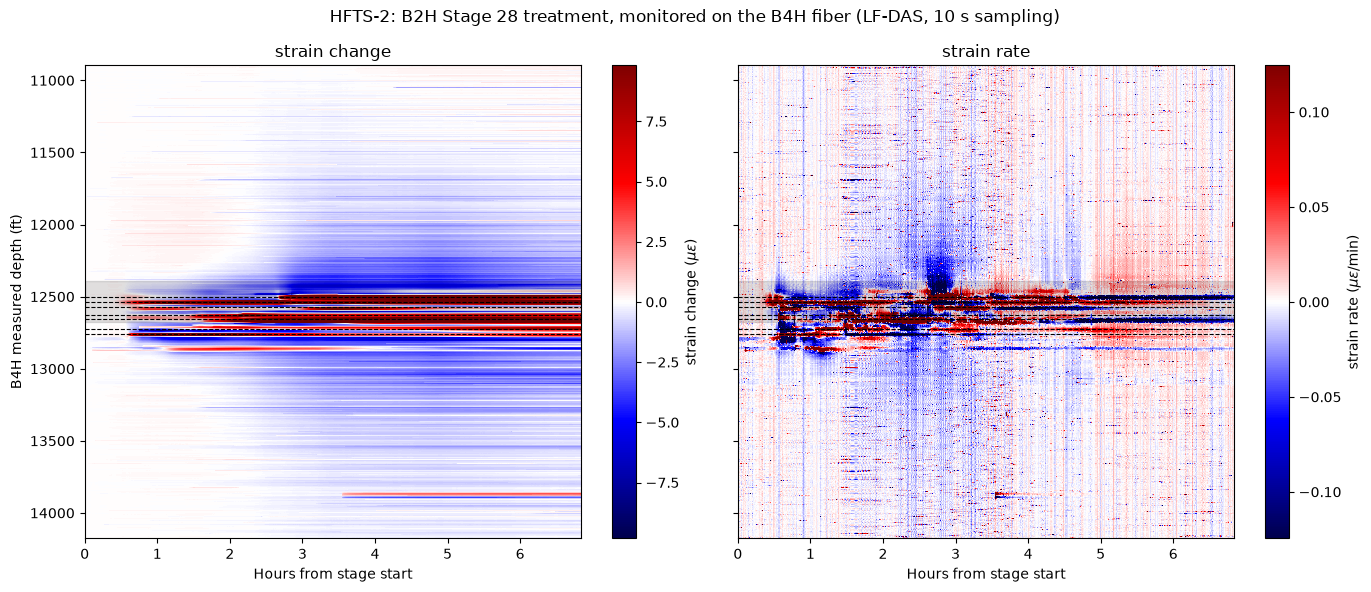

In [7]:
plot_case('B2H-28@B4H')

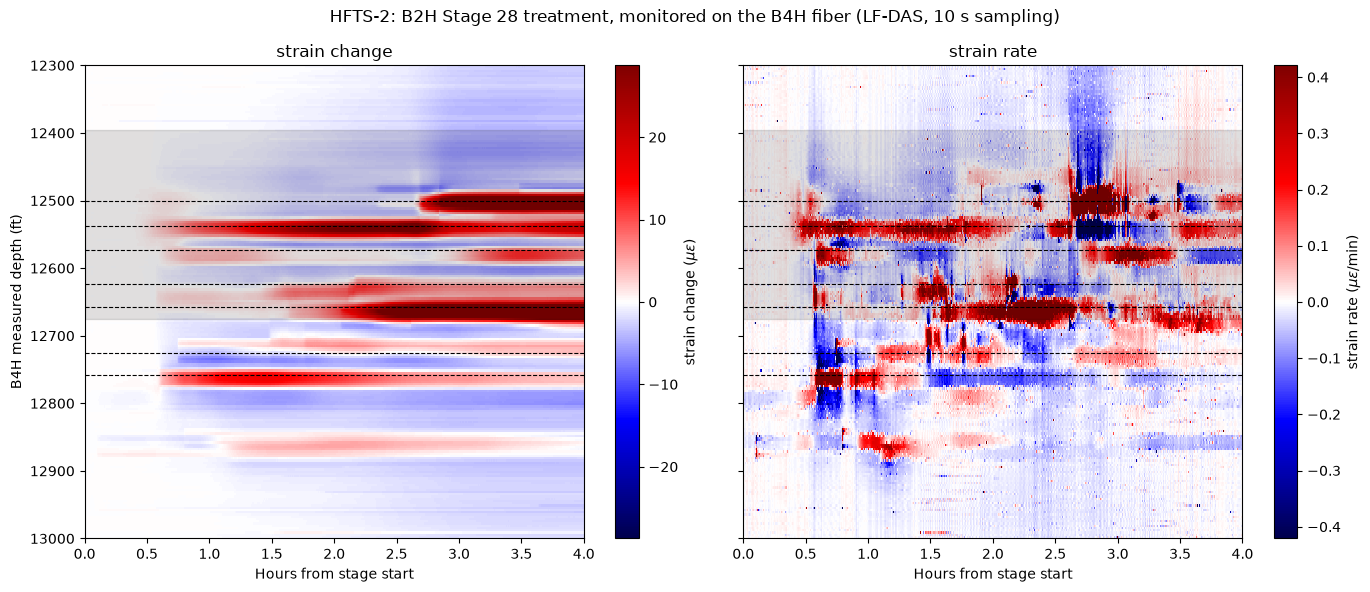

In [8]:
# zoomed view: fracture-hit corridor of stage 28, color scale restretched to the window
plot_case('B2H-28@B4H', save=False, tlim=(0.0, 4.0), dlim=(12300, 13000), rescale_clim=True)

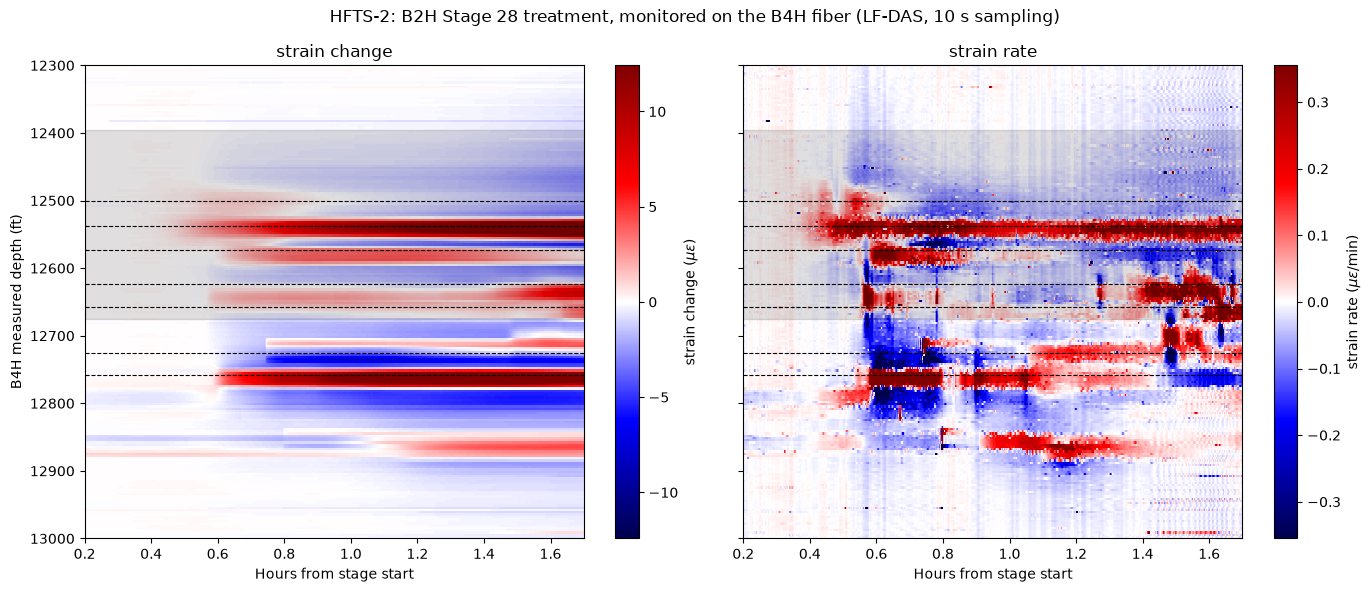

In [9]:
# reactivation frac
plot_case('B2H-28@B4H', save=True, tlim=(0.2, 1.7), dlim=(12300, 13000), rescale_clim=True, save_suffix="_reactivation_fracture_hits")

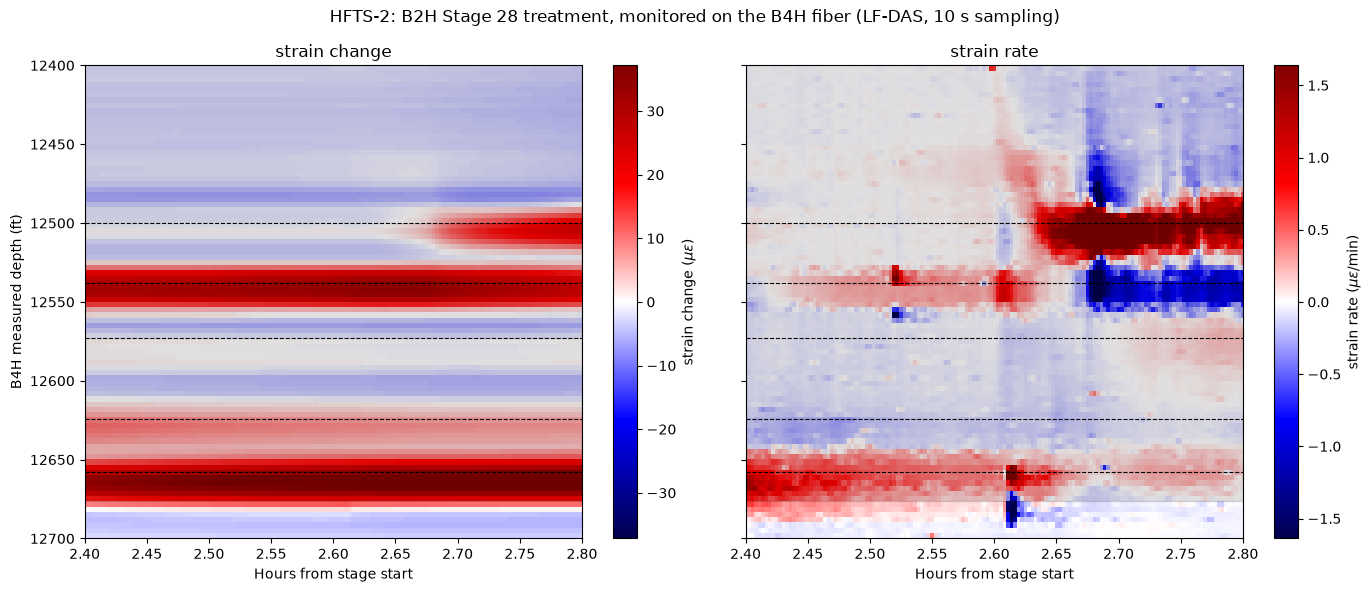

In [10]:
# new frac
plot_case('B2H-28@B4H', save=False, tlim=(2.4, 2.8), dlim=(12400, 12700), rescale_clim=True)